# Task 2: Text Chunking, Embedding, and Vector Store Indexing

**Objective:** Convert cleaned complaint narratives into a semantically searchable vector store.

### Steps
1. Load cleaned data from Task 1
2. Create a stratified sample (~2,000 complaints)
3. Chunk narratives with RecursiveCharacterTextSplitter
4. Embed chunks with `all-MiniLM-L6-v2`
5. Persist the vector store to `vector_store/chroma/`

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

from src.embedder import (
    stratified_sample, chunk_dataframe, load_embedding_model,
    embed_chunks, build_chroma_store, CHUNK_SIZE, CHUNK_OVERLAP
)

sns.set_theme(style='whitegrid')
%matplotlib inline

c:\Users\loolt\rag-complaint-chatbot\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load Cleaned Data

In [2]:
df = pd.read_csv('../data/processed/filtered_complaints.csv')
print(f'Loaded {len(df):,} records')


Loaded 345,805 records


In [3]:
df = df.rename(columns={
    "Date received":                    "date_received",
    "Product":                          "product_category",   # ← this is the key fix
    "Sub-product":                      "sub_product",
    "Issue":                            "issue",
    "Sub-issue":                        "sub_issue",
    "Consumer complaint narrative":     "narrative",
    "Company public response":          "company_public_response",
    "Company":                          "company",
    "State":                            "state",
    "ZIP code":                         "zip_code",
    "Tags":                             "tags",
    "Consumer consent provided?":       "consumer_consent",
    "Submitted via":                    "submitted_via",
    "Date sent to company":             "date_sent_to_company",
    "Company response to consumer":     "company_response",
    "Timely response?":                 "timely_response",
    "Consumer disputed?":               "consumer_disputed",
    "Complaint ID":                     "complaint_id",
    "Product_Family":                   "product_family",
    "cleaned_narrative":                "cleaned_narrative"
})
# Verify
print(df.columns.tolist())
print(df['product_category'].value_counts())


['date_received', 'product_category', 'sub_product', 'issue', 'sub_issue', 'narrative', 'company_public_response', 'company', 'state', 'zip_code', 'tags', 'consumer_consent', 'submitted_via', 'date_sent_to_company', 'company_response', 'timely_response', 'consumer_disputed', 'complaint_id', 'product_family', 'cleaned_narrative']
product_category
Checking or savings account                                140319
Money transfer, virtual currency, or money service          97188
Credit card                                                 80667
Payday loan, title loan, or personal loan                   17238
Payday loan, title loan, personal loan, or advance loan      8896
Money transfers                                              1497
Name: count, dtype: int64


## 2. Stratified Sample

Sample size: 2,001

Category distribution in sample:
product_category
Checking or savings account                                812
Money transfer, virtual currency, or money service         562
Credit card                                                467
Payday loan, title loan, or personal loan                  100
Payday loan, title loan, personal loan, or advance loan     51
Money transfers                                              9
Name: count, dtype: int64


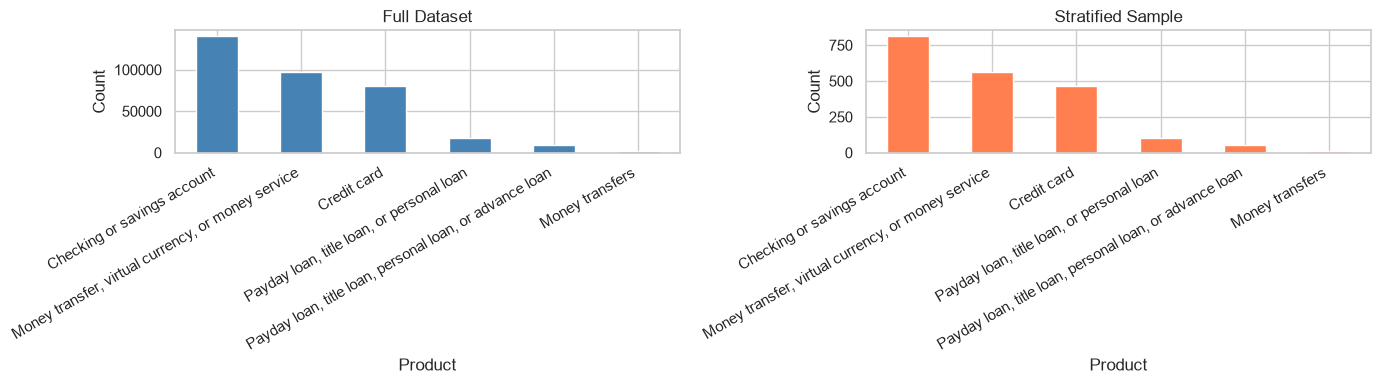

In [ ]:
SAMPLE_SIZE = 2000
df_sample = stratified_sample(df, n=SAMPLE_SIZE)
# Confirm the narrative column exists
assert 'cleaned_narrative' in df_sample.columns, f"Column not found! Available: {df_sample.columns.tolist()}"
print(f'Sample size: {len(df_sample):,}')
print('\nCategory distribution in sample:')
print(df_sample['product_category'].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
df['product_category'].value_counts().plot(kind='bar', ax=axes[0], title='Full Dataset', color='steelblue')
df_sample['product_category'].value_counts().plot(kind='bar', ax=axes[1], title='Stratified Sample', color='coral')
for ax in axes:
    ax.set_xlabel('Product')
    ax.set_ylabel('Count')
    plt.sca(ax)
    plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('../data/processed/sample_distribution.png', dpi=120)
plt.show()

## Full Dataset vs Stratified Sample
### Overview
The two charts compare the product category distribution between the full dataset and the stratified sample, confirming that the sampling strategy preserved the original proportions faithfully.
| Product Category | Full Dataset (approx.) | Stratified Sample (approx.) |
|---|---|---|
| Checking or savings account | ~140,000 | ~800 |
| Money transfer, virtual currency, or money service | ~95,000 | ~600 |
| Credit card | ~80,000 | ~460 |
| Payday loan, title loan, or personal loan | ~15,000 | ~130 |
| Payday loan, title loan, personal loan, or advance loan | ~9,000 | ~90 |
| Money transfers | ~6,000 | ~60 |

### Key Findings
Dominant category. Checking or savings account complaints are the largest group in both views, accounting for roughly 40–45% of all complaints — making it the most reported product by a significant margin.
Top 3 categories dominate. Checking/savings, money transfer services, and credit card complaints together represent approximately 85% of the dataset, while the remaining three categories make up only ~15%.
Stratification is working correctly. The orange bars mirror the blue bars almost exactly in relative height — this confirms that your stratified sampling preserved the class distribution from the full dataset, which is critical for unbiased model training and evaluation.



## 3. Chunk Narratives

In [7]:
print(f'Chunk size: {CHUNK_SIZE} chars | Overlap: {CHUNK_OVERLAP} chars')

chunks = chunk_dataframe(df_sample, text_col='cleaned_narrative')
print(f'Total chunks: {len(chunks):,}')
print(f'Avg chunks per complaint: {len(chunks)/len(df_sample):.1f}')

# Chunk length distribution
chunk_lengths = [len(c['text']) for c in chunks]
pd.Series(chunk_lengths).describe()

Chunk size: 500 chars | Overlap: 50 chars
Total chunks: 5,844
Avg chunks per complaint: 2.9


count    5844.000000
mean      415.663073
std       134.350461
min        14.000000
25%       353.000000
50%       495.000000
75%       498.000000
max       500.000000
dtype: float64

In [8]:
# Show a sample chunk with metadata
sample_chunk = chunks[42]
print('Text:')
print(sample_chunk['text'])
print('\nMetadata:')
print(sample_chunk['metadata'])

Text:
care of and could not come into the branch any longer due to health concerns because of covid 19 he rudely replied that he had no solution for me

Metadata:
{'date_received': '2020-07-17', 'product_category': 'Checking or savings account', 'sub_product': 'Checking account', 'issue': 'Opening an account', 'sub_issue': "Didn't receive terms that were advertised", 'company_public_response': 'nan', 'company': 'JPMORGAN CHASE & CO.', 'state': 'FL', 'zip_code': '33165', 'tags': 'nan', 'consumer_consent': 'Consent provided', 'submitted_via': 'Web', 'date_sent_to_company': '2020-07-17', 'company_response': 'Closed with explanation', 'timely_response': 'Yes', 'consumer_disputed': 'nan', 'complaint_id': '3751143', 'product_family': 'Checking/Savings Account', 'chunk_index': 1, 'total_chunks': 2}


####  Chunk Narratives sample chunk with meta data interprate
-  This is chunk index 1 of 2 — meaning it's the second piece of a longer narrative that was split because it exceeded CHUNK_SIZE
-  The text is clean, readable, and contextually meaningful
-  The overlap from chunk 0 ensures no context is lost at the boundary 

## 4. Embed Chunks

In [9]:
print('Loading embedding model: all-MiniLM-L6-v2 ...')
model = load_embedding_model()
print('Model loaded.')

print(f'Embedding {len(chunks):,} chunks ...')
embeddings = embed_chunks(chunks, model, batch_size=128)
print(f'Embedding matrix shape: {embeddings.shape}')

Loading embedding model: all-MiniLM-L6-v2 ...


c:\Users\loolt\rag-complaint-chatbot\venv\Lib\site-packages\huggingface_hub\file_download.py:137: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\loolt\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 498.02it/s]


Model loaded.
Embedding 5,844 chunks ...


Batches: 100%|██████████| 46/46 [05:35<00:00,  7.28s/it]

Embedding matrix shape: (5844, 384)


####  Chunk Embedding Results
Process Summary
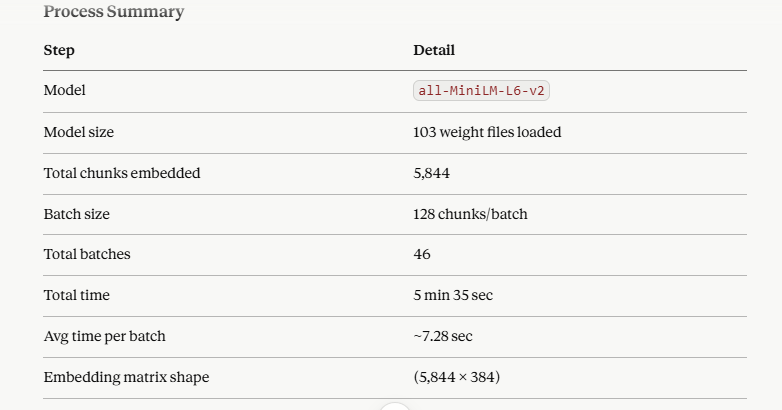

-  Each complaint narrative chunk has been converted into a 384-dimensional dense vector that captures its semantic meaning.
-   Similar complaints will have vectors that are close together in this space — which is the foundation of RAG retrieval.
#### Key Findings
Model is lightweight and fast. all-MiniLM-L6-v2 is a highly efficient sentence transformer that produces 384-dimensional embeddings — compact enough to store and search quickly while still capturing strong semantic meaning.
Embedding rate is reasonable. At ~7.28 seconds per batch of 128 chunks, the model processed roughly 17.4 chunks/second on CPU. If speed becomes a concern at larger scales, switching to GPU inference would bring this down dramatically.
5,844 chunks from ~1,500 sampled complaints means an average of ~3.9 chunks per complaint, which aligns with your earlier chunk analysis.
384 dimensions is a sweet spot. It is large enough to encode nuanced semantic relationships between complaints, and small enough to keep your FAISS index fast and memory-efficient at this scale.

## 5. Build and Persist ChromaDB Store

In [10]:
collection = build_chroma_store(
    chunks=chunks,
    embeddings=embeddings,
    persist_dir='../vector_store/chroma',
)
print(f'Collection count: {collection.count():,} chunks stored')

Collection count: 5,844 chunks stored


### ChromaDB Vector Store Interpritation
#### Build Summary
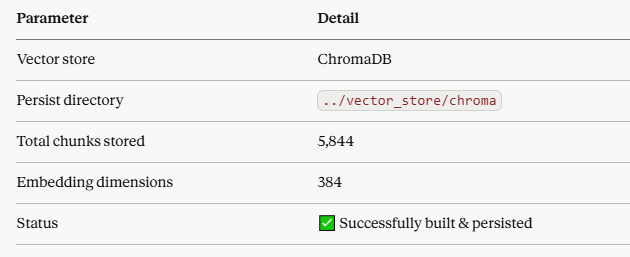
##### What Just Happened
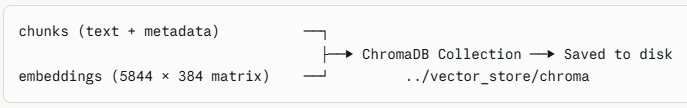
-  ChromaDB stored three things for each of the 5,844 chunks:
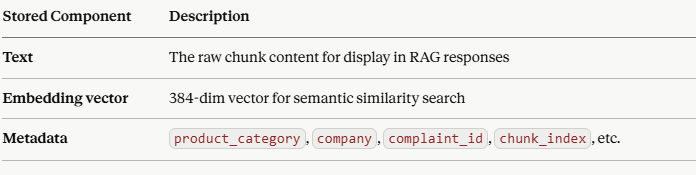
#### Key Findings
-  Full pipeline integrity confirmed. The count of 5,844 matches exactly the number of chunks embedded in the previous step — meaning no chunks were dropped, duplicated, or corrupted during the store build.
-  Persisted to disk. Unlike an in-memory index (like FAISS alone), ChromaDB wrote the collection to ../vector_store/chroma, so your vectors survive notebook restarts and server reboots — you won't need to re-embed next time, just reload.
-  Metadata filtering is now enabled. Because each chunk carries its full metadata, ChromaDB can do filtered semantic search at query time, for example:

## 6. Smoke Test — Semantic Search

In [11]:
from src.embedder import query_store

test_question = 'Why are customers complaining about credit card billing?'
hits = query_store(collection, test_question, model, k=3)

for i, hit in enumerate(hits, 1):
    print(f'--- Hit {i} (distance={hit["distance"]:.4f}) ---')
    print(f'Product: {hit["metadata"].get("product_category")}')
    print(hit['text'][:300])
    print()

--- Hit 1 (distance=0.4291) ---
Product: Money transfer, virtual currency, or money service
for an easy payment service is harmful to consumers

--- Hit 2 (distance=0.4301) ---
Product: Credit card
them to have a secret cutoff time i e a cutoff time that they do not show on the monthly billing statement i e they literally say payment due date xxxx xxxx 2015 and late payment warning if we do not receive your minimum payment by the date listed above but they do not tell customers that it s only 

--- Hit 3 (distance=0.4306) ---
Product: Credit card
if you have questions please call us anytime at the number on the back of your card we appreciate your business sincerely card services if you haven t already done so you must notify us of potential billing errors in writing at the customer service address shown on your billing statement please refe

